<h1>Lab 1 Ex. 1: Image Denoising with Neural Networks</h1>

In [48]:
# from google.colab import drive
# drive.mount('/content/drive')

Unizp training and test data

In [49]:
# !unzip /content/Dataset.zip -d /content/Dataset
from pathlib import Path

train_folder = Path("/content/Dataset/Dataset/train_dn")
test_folder = Path("/content/Dataset/Dataset/test_dn")

# train_folder = Path("./Dataset/train_dn")
# test_folder = Path("./Dataset/test_dn")

**[TODO]** Here are all the import statements needed for all the exercises

In [50]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from PIL import Image

**[TODO]** Create a torch dataset. It must return a tuple with a float32 tensor for the noisy image patch and another float32 tensor for the clean image patch. Patches values should be normalized.

Patch must be extracted as a 32x32 crop of the image file at a random position. Noise is additive white Gaussian noise with standard deviation equal to 25. Note that images are provided in the PNG file format.

Hint: look into torchivison transforms for random crop.

N.B.: 25 is the standard deviation on the original [0,255] scale of image intensity. If you normalize the images, be careful about it!

In [51]:
class ImageDenoisingDataset(Dataset):
    def __init__(self, folder=None, image_files=None, random_crop=True, patch_size=32, noise_std=25.0):
        self.folder = folder
        self.image_files = list(sorted(image_files)) if image_files is not None else list(sorted(folder.glob("*.png")))
        self.random_crop = random_crop
        self.patch_size = patch_size
        self.noise_std = noise_std

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_path = self.image_files[idx]
        image = Image.open(image_path).convert("L") # convert to grayscale

        if self.random_crop:
            w, h = image.size
            if w < self.patch_size or h < self.patch_size:
                raise ValueError(f"Image {image_path} too small for {self.patch_size}x{self.patch_size} crop")
            x = np.random.randint(0, w - self.patch_size + 1)
            y = np.random.randint(0, h - self.patch_size + 1)
            image = image.crop((x, y, x + self.patch_size, y + self.patch_size))

        # convert to numpy array
        clean_patch = np.array(image).astype(np.float32)

        # add white Gaussian noise with std 25 (in [0,255] scale)
        noise = np.random.randn(*clean_patch.shape).astype(np.float32) * self.noise_std
        noise_patch = clean_patch + noise
        noise_patch = np.clip(noise_patch, 0.0, 255.0)

        # normalize to [0, 1]
        clean_patch = clean_patch / 255.0
        noise_patch = noise_patch / 255.0

        # convert to tensors
        clean_patch = torch.from_numpy(clean_patch).float()
        noise_patch = torch.from_numpy(noise_patch).float()

        return clean_patch, noise_patch

**[TODO]** Instantiate a Dataset and create a Dataloader for the training and test sets

In [52]:
batch_size = 32

all_train_files = list(sorted(train_folder.glob("*.png")))
all_test_files = list(sorted(test_folder.glob("*.png")))

# train: random 32x32 crops
train_dataset = ImageDenoisingDataset(image_files=all_train_files, random_crop=True, patch_size=32)

# test: full images
test_dataset = ImageDenoisingDataset(image_files=all_test_files, random_crop=False)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

**[TODO]** Define the neural network. You will use a shorter version of DnCNN with only 8 blocks of Conv-BN-RELU. Remember to use the residual trick. After completing the exercise, try defining a new model without the residual trick and check how it performs.

In [53]:
class shorterDnCNN(nn.Module):
    def __init__(self, num_blocks=8, num_channels=128):
        super().__init__()

        # Head convolution
        self.conv1 = nn.Conv2d(1, num_channels, 3, padding=1)
        self.relu1 = nn.ReLU(inplace=True)

        # 8 Conv-BN-ReLU blocks as requested in the assignment
        layers = []
        for _ in range(num_blocks):
            layers.append(nn.Conv2d(num_channels, num_channels, 3, padding=1, bias=False))
            layers.append(nn.BatchNorm2d(num_channels))
            layers.append(nn.ReLU(inplace=True))
        self.blocks = nn.Sequential(*layers)

        # Tail convolution that predicts the residual noise
        self.conv_last = nn.Conv2d(num_channels, 1, 3, padding=1)

    def forward(self, x):
        x = self.relu1(self.conv1(x))
        x = self.blocks(x)
        predicted_noise = self.conv_last(x)
        return predicted_noise


class shorterDnCNN_without_residual(nn.Module):
    def __init__(self, num_blocks=8, num_channels=128):
        super().__init__()

        self.conv1 = nn.Conv2d(1, num_channels, 3, padding=1)
        self.relu1 = nn.ReLU(inplace=True)

        layers = []
        for _ in range(num_blocks):
            layers.append(nn.Conv2d(num_channels, num_channels, 3, padding=1, bias=False))
            layers.append(nn.BatchNorm2d(num_channels))
            layers.append(nn.ReLU(inplace=True))
        self.blocks = nn.Sequential(*layers)

        # Directly predicts the clean image (no residual trick)
        self.conv_last = nn.Conv2d(num_channels, 1, 3, padding=1)

    def forward(self, x):
        x = self.relu1(self.conv1(x))
        x = self.blocks(x)
        clean_hat = self.conv_last(x)
        return clean_hat

**[TODO]** Instantiate the DnCNN model, move it GPU, and define an optimizer

In [54]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = shorterDnCNN()
model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
print(model)
print(f"Device: {device}")

shorterDnCNN(
  (conv1): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU(inplace=True)
  (blocks): Sequential(
    (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): Conv2d(128, 128

In [55]:
model_without_residual = shorterDnCNN_without_residual()
model_without_residual.to(device)
optimizer_without_residual = torch.optim.Adam(model_without_residual.parameters(), lr=5e-4)
print(model_without_residual)
print(f"Device: {device}")

shorterDnCNN_without_residual(
  (conv1): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU(inplace=True)
  (blocks): Sequential(
    (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12)

**[TODO]** Train the model

In [56]:
print(f"Using device {device} for model with residual connection")

criterion = nn.MSELoss()
num_epochs = 75
avg_train_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for clean_patches, noise_patches in train_loader:
        # grayscale patches are (B, H, W) -> convert to (B, C, H, W) with C=1
        clean_patches = clean_patches.unsqueeze(1).to(device)
        noise_patches = noise_patches.unsqueeze(1).to(device)

        # Residual model must predict NOISE
        noise = noise_patches - clean_patches

        optimizer.zero_grad()
        outputs = model(noise_patches)
        loss = criterion(outputs, noise)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * clean_patches.size(0)

    avg_train_loss = train_loss / len(train_loader.dataset)
    avg_train_losses.append(avg_train_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}")

Using device cuda for model with residual connection
Epoch [5/75], Train Loss: 0.0043
Epoch [10/75], Train Loss: 0.0032
Epoch [15/75], Train Loss: 0.0028
Epoch [20/75], Train Loss: 0.0025
Epoch [25/75], Train Loss: 0.0024
Epoch [30/75], Train Loss: 0.0023
Epoch [35/75], Train Loss: 0.0024
Epoch [40/75], Train Loss: 0.0022
Epoch [45/75], Train Loss: 0.0021
Epoch [50/75], Train Loss: 0.0021
Epoch [55/75], Train Loss: 0.0022
Epoch [60/75], Train Loss: 0.0020
Epoch [65/75], Train Loss: 0.0021
Epoch [70/75], Train Loss: 0.0019
Epoch [75/75], Train Loss: 0.0020


In [57]:
print(f"Using device {device} for model without residual connection")

criterion = nn.MSELoss()
num_epochs = 75
avg_train_losses_without_residual = []

for epoch in range(num_epochs):
    model_without_residual.train()
    train_loss = 0.0
    for clean_patches, noise_patches in train_loader:
        # grayscale patches are (B, H, W) -> convert to (B, C, H, W) with C=1
        clean_patches = clean_patches.unsqueeze(1).to(device)
        noise_patches = noise_patches.unsqueeze(1).to(device)

        optimizer_without_residual.zero_grad()
        outputs = model_without_residual(noise_patches)
        # No-residual model is trained to directly predict the clean image
        loss = criterion(outputs, clean_patches)
        loss.backward()
        optimizer_without_residual.step()

        train_loss += loss.item() * clean_patches.size(0)

    avg_train_loss = train_loss / len(train_loader.dataset)
    avg_train_losses_without_residual.append(avg_train_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}")

Using device cuda for model without residual connection
Epoch [5/75], Train Loss: 0.0077
Epoch [10/75], Train Loss: 0.0053
Epoch [15/75], Train Loss: 0.0067
Epoch [20/75], Train Loss: 0.0052
Epoch [25/75], Train Loss: 0.0056
Epoch [30/75], Train Loss: 0.0048
Epoch [35/75], Train Loss: 0.0115
Epoch [40/75], Train Loss: 0.0054
Epoch [45/75], Train Loss: 0.0044
Epoch [50/75], Train Loss: 0.0060
Epoch [55/75], Train Loss: 0.0043
Epoch [60/75], Train Loss: 0.0040
Epoch [65/75], Train Loss: 0.0053
Epoch [70/75], Train Loss: 0.0036
Epoch [75/75], Train Loss: 0.0040


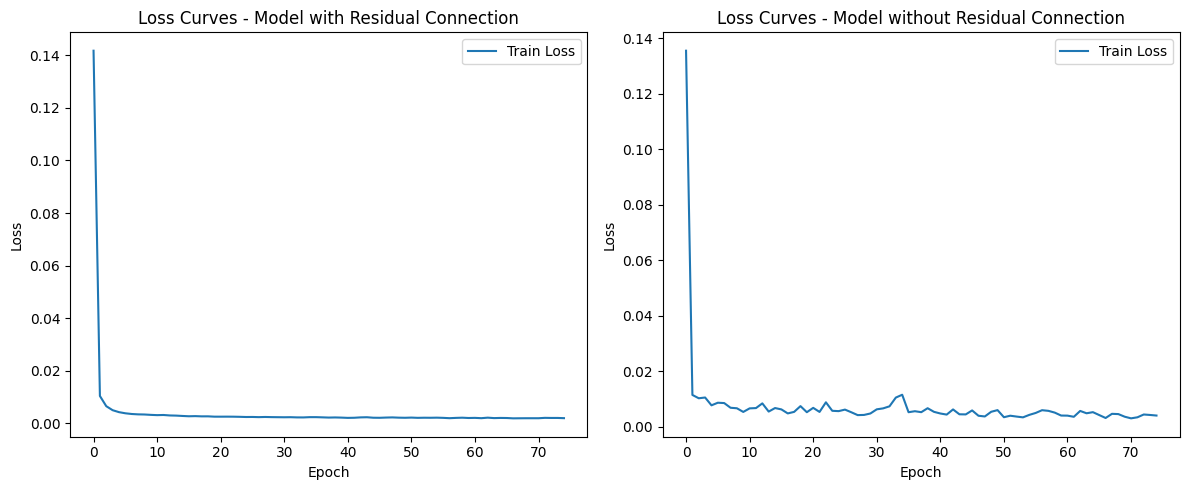

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(avg_train_losses, label='Train Loss')
plt.title('Loss Curves - Model with Residual Connection')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(avg_train_losses_without_residual, label='Train Loss')
plt.title('Loss Curves - Model without Residual Connection')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

**[TODO]** Test the denoiser on the test images. Load an image, corrupt it with noise and use the model to denoise it. Measure the PSNR in dB of the denoised image with respect to the clean one. Visualize a clean, noisy and denoised image.

In [66]:
# compute the PSNR of noisy test image respect to its clean version
def compute_psnr(clean, noisy):
    mse = torch.mean((clean - noisy) ** 2)
    if mse == 0:
        return float('inf')
    psnr = 10 * torch.log10(1 / mse)
    return psnr.item()

# compute the PSNR of denoised test image respect to its clean version
def compute_psnr_denoised(clean, denoised):
    mse = torch.mean((clean - denoised) ** 2)
    if mse == 0:
        return float('inf')
    psnr = 10 * torch.log10(1 / mse)
    return psnr.item()

psnr_noisy = []
psnr_denoised_with_residual = []
psnr_denoised_without_residual = []

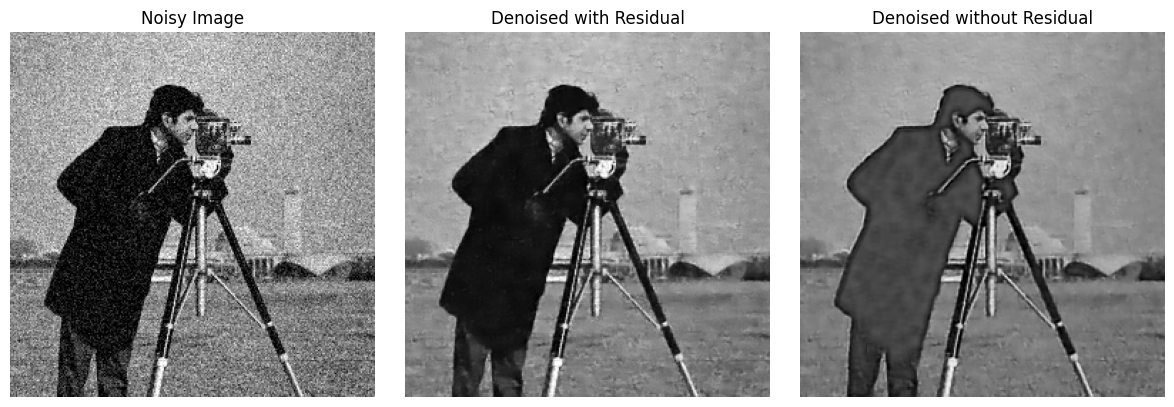


Test Loss with residual connection (noise prediction): 0.0017
Test Loss without residual connection (clean prediction): 0.0053
Average PSNR of Noisy Patches: 20.34 dB
Average PSNR of Denoised Patches with Residual Connection: 27.87 dB
Average PSNR of Denoised Patches without Residual Connection: 23.17 dB


In [67]:
test_loss = 0.0
test_loss_without_residual = 0.0

model.eval()
model_without_residual.eval()

with torch.no_grad():
    for clean_patches, noise_patches in test_loader:
        clean_patches = clean_patches.unsqueeze(1).to(device)
        noise_patches = noise_patches.unsqueeze(1).to(device)

        # Residual model predicts noise, then denoised = noisy - predicted_noise
        predicted_noise = model(noise_patches)
        denoised = noise_patches - predicted_noise

        # No-residual model directly predicts the clean image
        denoised_without_residual = model_without_residual(noise_patches)

        # Clamp outputs to valid image range before visualization/PSNR
        denoised = torch.clamp(denoised, 0.0, 1.0)
        denoised_without_residual = torch.clamp(denoised_without_residual, 0.0, 1.0)

        noise = noise_patches - clean_patches

        # show first full test image (noisy vs denoised with/without residual)
        if len(psnr_noisy) == 0:
            fig, axes = plt.subplots(1, 3, figsize=(12, 4))

            axes[0].imshow(noise_patches[0].cpu().squeeze(), cmap='gray')
            axes[0].set_title('Noisy Image')
            axes[0].axis('off')

            axes[1].imshow(denoised[0].cpu().squeeze(), cmap='gray')
            axes[1].set_title('Denoised with Residual')
            axes[1].axis('off')

            axes[2].imshow(denoised_without_residual[0].cpu().squeeze(), cmap='gray')
            axes[2].set_title('Denoised without Residual')
            axes[2].axis('off')

            plt.tight_layout()
            plt.show()

        # Evaluate each model against its proper target
        loss = criterion(predicted_noise, noise)
        loss_without_residual = criterion(denoised_without_residual, clean_patches)

        test_loss += loss.item() * noise_patches.size(0)
        test_loss_without_residual += loss_without_residual.item() * noise_patches.size(0)

        psnr_noisy.append(compute_psnr(clean_patches, noise_patches))
        psnr_denoised_with_residual.append(compute_psnr_denoised(clean_patches, denoised))
        psnr_denoised_without_residual.append(compute_psnr_denoised(clean_patches, denoised_without_residual))

avg_test_loss = test_loss / len(test_loader.dataset)
avg_test_loss_without_residual = test_loss_without_residual / len(test_loader.dataset)
avg_psnr_noisy = np.mean(psnr_noisy)
avg_psnr_denoised_with_residual = np.mean(psnr_denoised_with_residual)
avg_psnr_denoised_without_residual = np.mean(psnr_denoised_without_residual)

print(f'\nTest Loss with residual connection (noise prediction): {avg_test_loss:.4f}')
print(f'Test Loss without residual connection (clean prediction): {avg_test_loss_without_residual:.4f}')

print(f'Average PSNR of Noisy Patches: {avg_psnr_noisy:.2f} dB')
print(f'Average PSNR of Denoised Patches with Residual Connection: {avg_psnr_denoised_with_residual:.2f} dB')
print(f'Average PSNR of Denoised Patches without Residual Connection: {avg_psnr_denoised_without_residual:.2f} dB')

**[TODO]** Test the pretrained network with the residual trick on test images where the noise has
standard deviation equal to 10 and to 50 and report the resulting PSNRs

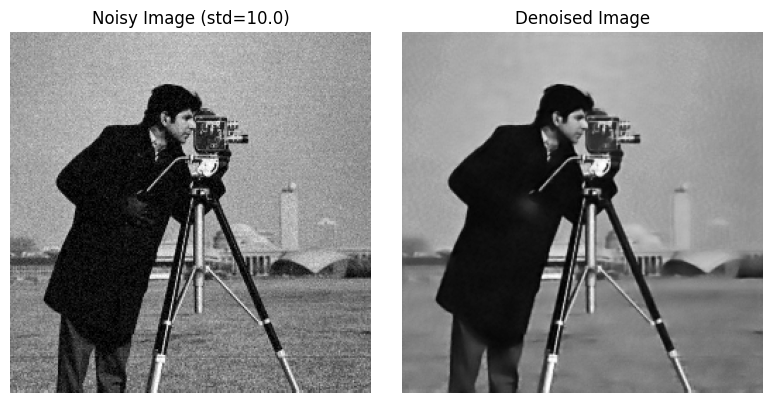


Noise STD: 10.0, Average PSNR of Noisy Patches: 28.16 dB, Average PSNR of Denoised Patches: 29.44 dB


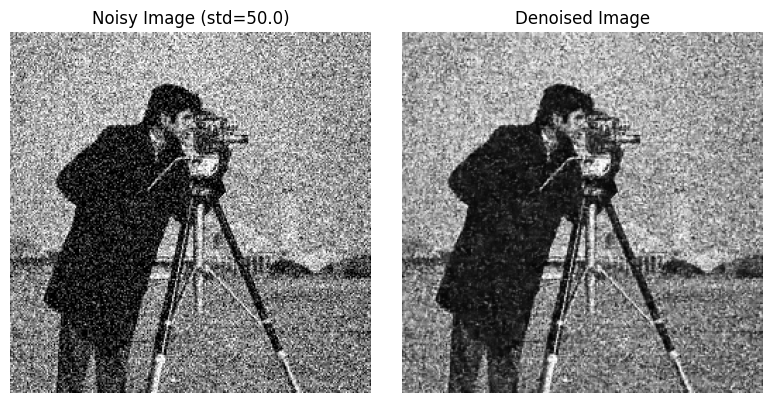


Noise STD: 50.0, Average PSNR of Noisy Patches: 14.77 dB, Average PSNR of Denoised Patches: 18.19 dB


In [68]:
# Test a pretrained network at a different noise level than training

model.eval()

def test_with_different_noise_levels(model, noise_std, predicts_noise=True):
    psnr_noisy = []
    psnr_denoised = []

    with torch.no_grad():
        for clean_patches, _ in test_loader:
            clean_patches = clean_patches.unsqueeze(1).to(device)

            # add noise with specified std
            noise = torch.randn_like(clean_patches) * (noise_std / 255.0)
            noisy_patches = clean_patches + noise
            noisy_patches = torch.clamp(noisy_patches, 0.0, 1.0)

            outputs = model(noisy_patches)
            denoised = noisy_patches - outputs if predicts_noise else outputs
            denoised = torch.clamp(denoised, 0.0, 1.0)

            # show first full test image (noisy vs denoised)
            if len(psnr_noisy) == 0:
                fig, axes = plt.subplots(1, 2, figsize=(8, 4))

                axes[0].imshow(noisy_patches[0].cpu().squeeze(), cmap='gray')
                axes[0].set_title(f'Noisy Image (std={noise_std})')
                axes[0].axis('off')

                axes[1].imshow(denoised[0].cpu().squeeze(), cmap='gray')
                axes[1].set_title('Denoised Image')
                axes[1].axis('off')

                plt.tight_layout()
                plt.show()

            psnr_noisy.append(compute_psnr(clean_patches, noisy_patches))
            psnr_denoised.append(compute_psnr_denoised(clean_patches, denoised))

    avg_psnr_noisy = np.mean(psnr_noisy)
    avg_psnr_denoised = np.mean(psnr_denoised)

    print(f'\nNoise STD: {noise_std}, Average PSNR of Noisy Patches: {avg_psnr_noisy:.2f} dB, Average PSNR of Denoised Patches: {avg_psnr_denoised:.2f} dB')

# model uses residual/noise prediction
test_with_different_noise_levels(model, noise_std=10.0, predicts_noise=True)
test_with_different_noise_levels(model, noise_std=50.0, predicts_noise=True)

**[TODO]** Now train a new DnCNN where the dataloader chooses the standard deviation
uniformly at random in the [10,50] interval instead of fixing it to 25, for each batch item
(this is called blind training). Test it on test images with standard deviations 10, 25, 50.

In [62]:
# Now train a new DnCNN where the dataloader chooses the standard deviation uniformly at random in the [10,50] interval instead of fixing it to 25, for each batch item (this is called blind training). Test it on test images with standard deviations 10, 25, 50.

class ImageDenoisingDatasetBlind(Dataset):
    def __init__(self, folder=None, image_files=None, random_crop=True, patch_size=32, noise_std_range=(10.0, 50.0)):
        self.folder = folder
        self.image_files = list(sorted(image_files)) if image_files is not None else list(sorted(folder.glob("*.png")))
        self.random_crop = random_crop
        self.patch_size = patch_size
        self.noise_std_range = noise_std_range

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_path = self.image_files[idx]
        image = Image.open(image_path).convert("L")

        if self.random_crop:
            w, h = image.size
            if w < self.patch_size or h < self.patch_size:
                raise ValueError(f"Image {image_path} too small for {self.patch_size}x{self.patch_size} crop")
            x = np.random.randint(0, w - self.patch_size + 1)
            y = np.random.randint(0, h - self.patch_size + 1)
            image = image.crop((x, y, x + self.patch_size, y + self.patch_size))

        # convert to numpy array
        clean_patch = np.array(image).astype(np.float32)

        # randomly choose noise std in the specified range
        noise_std = np.random.uniform(self.noise_std_range[0], self.noise_std_range[1])

        # add white Gaussian noise with the chosen std (in [0,255] scale)
        noise = np.random.randn(*clean_patch.shape).astype(np.float32) * noise_std
        noise_patch = clean_patch + noise
        noise_patch = np.clip(noise_patch, 0.0, 255.0)

        # normalize to [0, 1]
        clean_patch = clean_patch / 255.0
        noise_patch = noise_patch / 255.0

        # convert to tensors
        clean_patch = torch.from_numpy(clean_patch).float()
        noise_patch = torch.from_numpy(noise_patch).float()

        return clean_patch, noise_patch

# Create new datasets and dataloaders for blind training
train_dataset_blind = ImageDenoisingDatasetBlind(image_files=all_train_files, random_crop=True, patch_size=32)
test_dataset_blind = ImageDenoisingDatasetBlind(image_files=all_test_files, random_crop=False)

train_loader_blind = DataLoader(train_dataset_blind, batch_size=batch_size, shuffle=True)
test_loader_blind = DataLoader(test_dataset_blind, batch_size=1, shuffle=False)

In [63]:
model_blind = shorterDnCNN()
model_blind.to(device)
optimizer_blind = torch.optim.Adam(model_blind.parameters(), lr=2e-4)

criterion = nn.MSELoss()
num_epochs = 75
avg_train_losses_blind = []

for epoch in range(num_epochs):
    model_blind.train()
    train_loss = 0.0
    for clean_patches, noise_patches in train_loader_blind:
        clean_patches = clean_patches.unsqueeze(1).to(device)
        noise_patches = noise_patches.unsqueeze(1).to(device)

        # Residual model must predict NOISE
        noise = noise_patches - clean_patches

        optimizer_blind.zero_grad()
        outputs = model_blind(noise_patches)
        loss = criterion(outputs, noise)
        loss.backward()
        optimizer_blind.step()

        train_loss += loss.item() * clean_patches.size(0)

    avg_train_loss = train_loss / len(train_loader_blind.dataset)
    avg_train_losses_blind.append(avg_train_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}")

Epoch [5/75], Train Loss: 0.0063
Epoch [10/75], Train Loss: 0.0046
Epoch [15/75], Train Loss: 0.0040
Epoch [20/75], Train Loss: 0.0037
Epoch [25/75], Train Loss: 0.0036
Epoch [30/75], Train Loss: 0.0034
Epoch [35/75], Train Loss: 0.0031
Epoch [40/75], Train Loss: 0.0033
Epoch [45/75], Train Loss: 0.0029
Epoch [50/75], Train Loss: 0.0031
Epoch [55/75], Train Loss: 0.0032
Epoch [60/75], Train Loss: 0.0030
Epoch [65/75], Train Loss: 0.0030
Epoch [70/75], Train Loss: 0.0028
Epoch [75/75], Train Loss: 0.0027


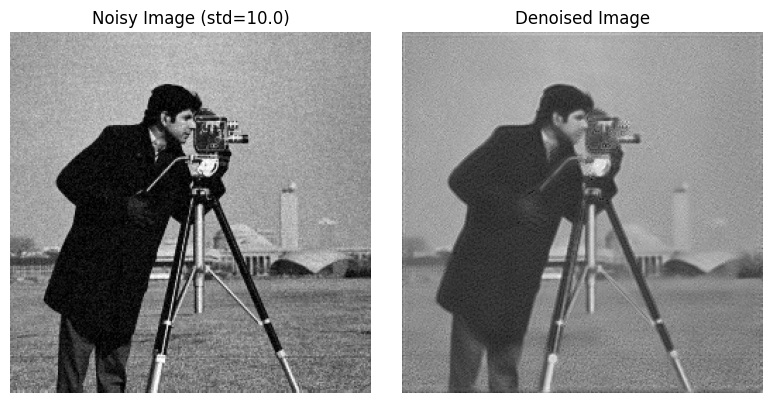


Noise STD: 10.0, Average PSNR of Noisy Patches: 28.16 dB, Average PSNR of Denoised Patches: 22.65 dB


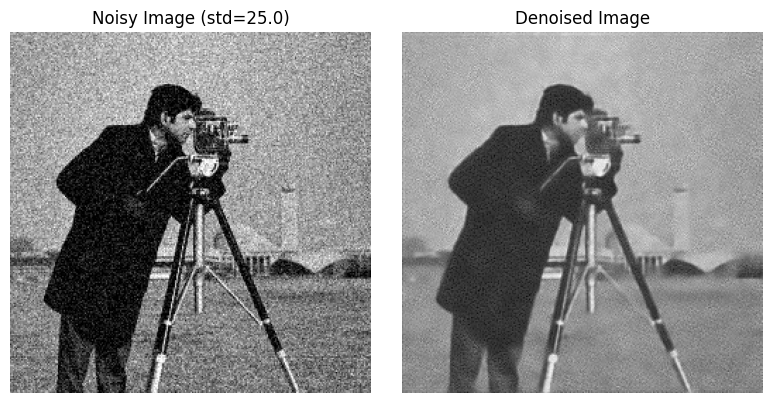


Noise STD: 25.0, Average PSNR of Noisy Patches: 20.33 dB, Average PSNR of Denoised Patches: 23.23 dB


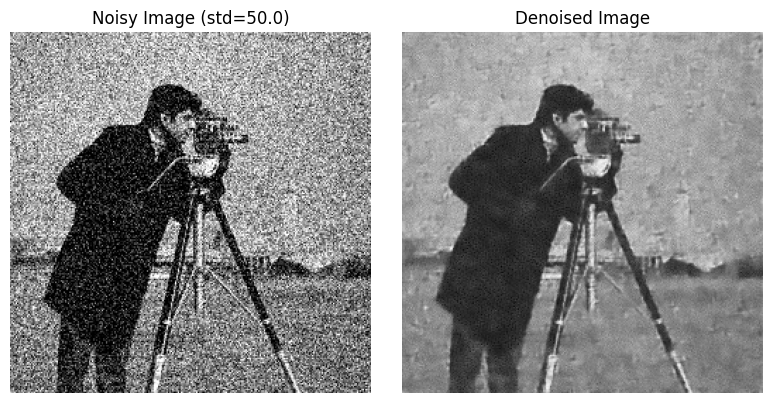


Noise STD: 50.0, Average PSNR of Noisy Patches: 14.76 dB, Average PSNR of Denoised Patches: 23.34 dB


In [64]:
for noise_std in [10.0, 25.0, 50.0]:
    test_with_different_noise_levels(model_blind, noise_std)